In [1]:
from model.data import BeamData, Plan

In [2]:
pat_dir = '/workspace/DoseRAD2026Dev/data/DoseRAD2026/photon/training/1ABB006'
plan = Plan(
    img_file_path=rf"{pat_dir}/image/ct.mha",
    info_json_path=rf"{pat_dir}/1ABB006.json",
    dose_dir=rf"{pat_dir}/dose",
)
print(plan.beam_info)

d = BeamData(plan)

OrderedDict([(0, {'sad': 1000, 'isocentre': [-46.8471844842125, 27.777663262437926, -28.13538836315937], 'n_mlc_leaf': 80, 'n_cp': 180}), (1, {'sad': 1000, 'isocentre': [-46.8471844842125, 27.777663262437926, -8.135388363159374], 'n_mlc_leaf': 80, 'n_cp': 180}), (2, {'sad': 1000, 'isocentre': [-46.8471844842125, 27.777663262437926, 11.864611636840626], 'n_mlc_leaf': 80, 'n_cp': 180})])


Reading files: 100%|██████████| 180/180 [00:10<00:00, 17.65it/s]


Starting parallel load with 32 threads...

Finished. Final array shape: (180, 246, 246, 249)
Data type: float16


Rotating image: 100%|██████████| 6/6 [00:04<00:00,  1.24it/s]


Grid created


Calulating BEV beam path: 100%|██████████| 6/6 [00:08<00:00,  1.35s/it]


In [4]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:           499Gi        67Gi        79Gi       185Mi       352Gi       427Gi
Swap:             0B          0B          0B


In [4]:
self = d

In [5]:
self.rot_input_tensor.shape

torch.Size([30, 246, 246, 249])

In [6]:
self.bev.shape, self.img_rot.shape, self.dose.shape

(torch.Size([180, 246, 246, 249]),
 torch.Size([180, 246, 246, 249]),
 torch.Size([180, 246, 246, 249]))

In [7]:
self.bev.dtype, self.img_rot.dtype, self.dose.dtype

(torch.uint8, torch.float32, torch.float16)

In [8]:
import matplotlib.pyplot as plt

In [10]:
d.cp_info[0]['ga']

-180

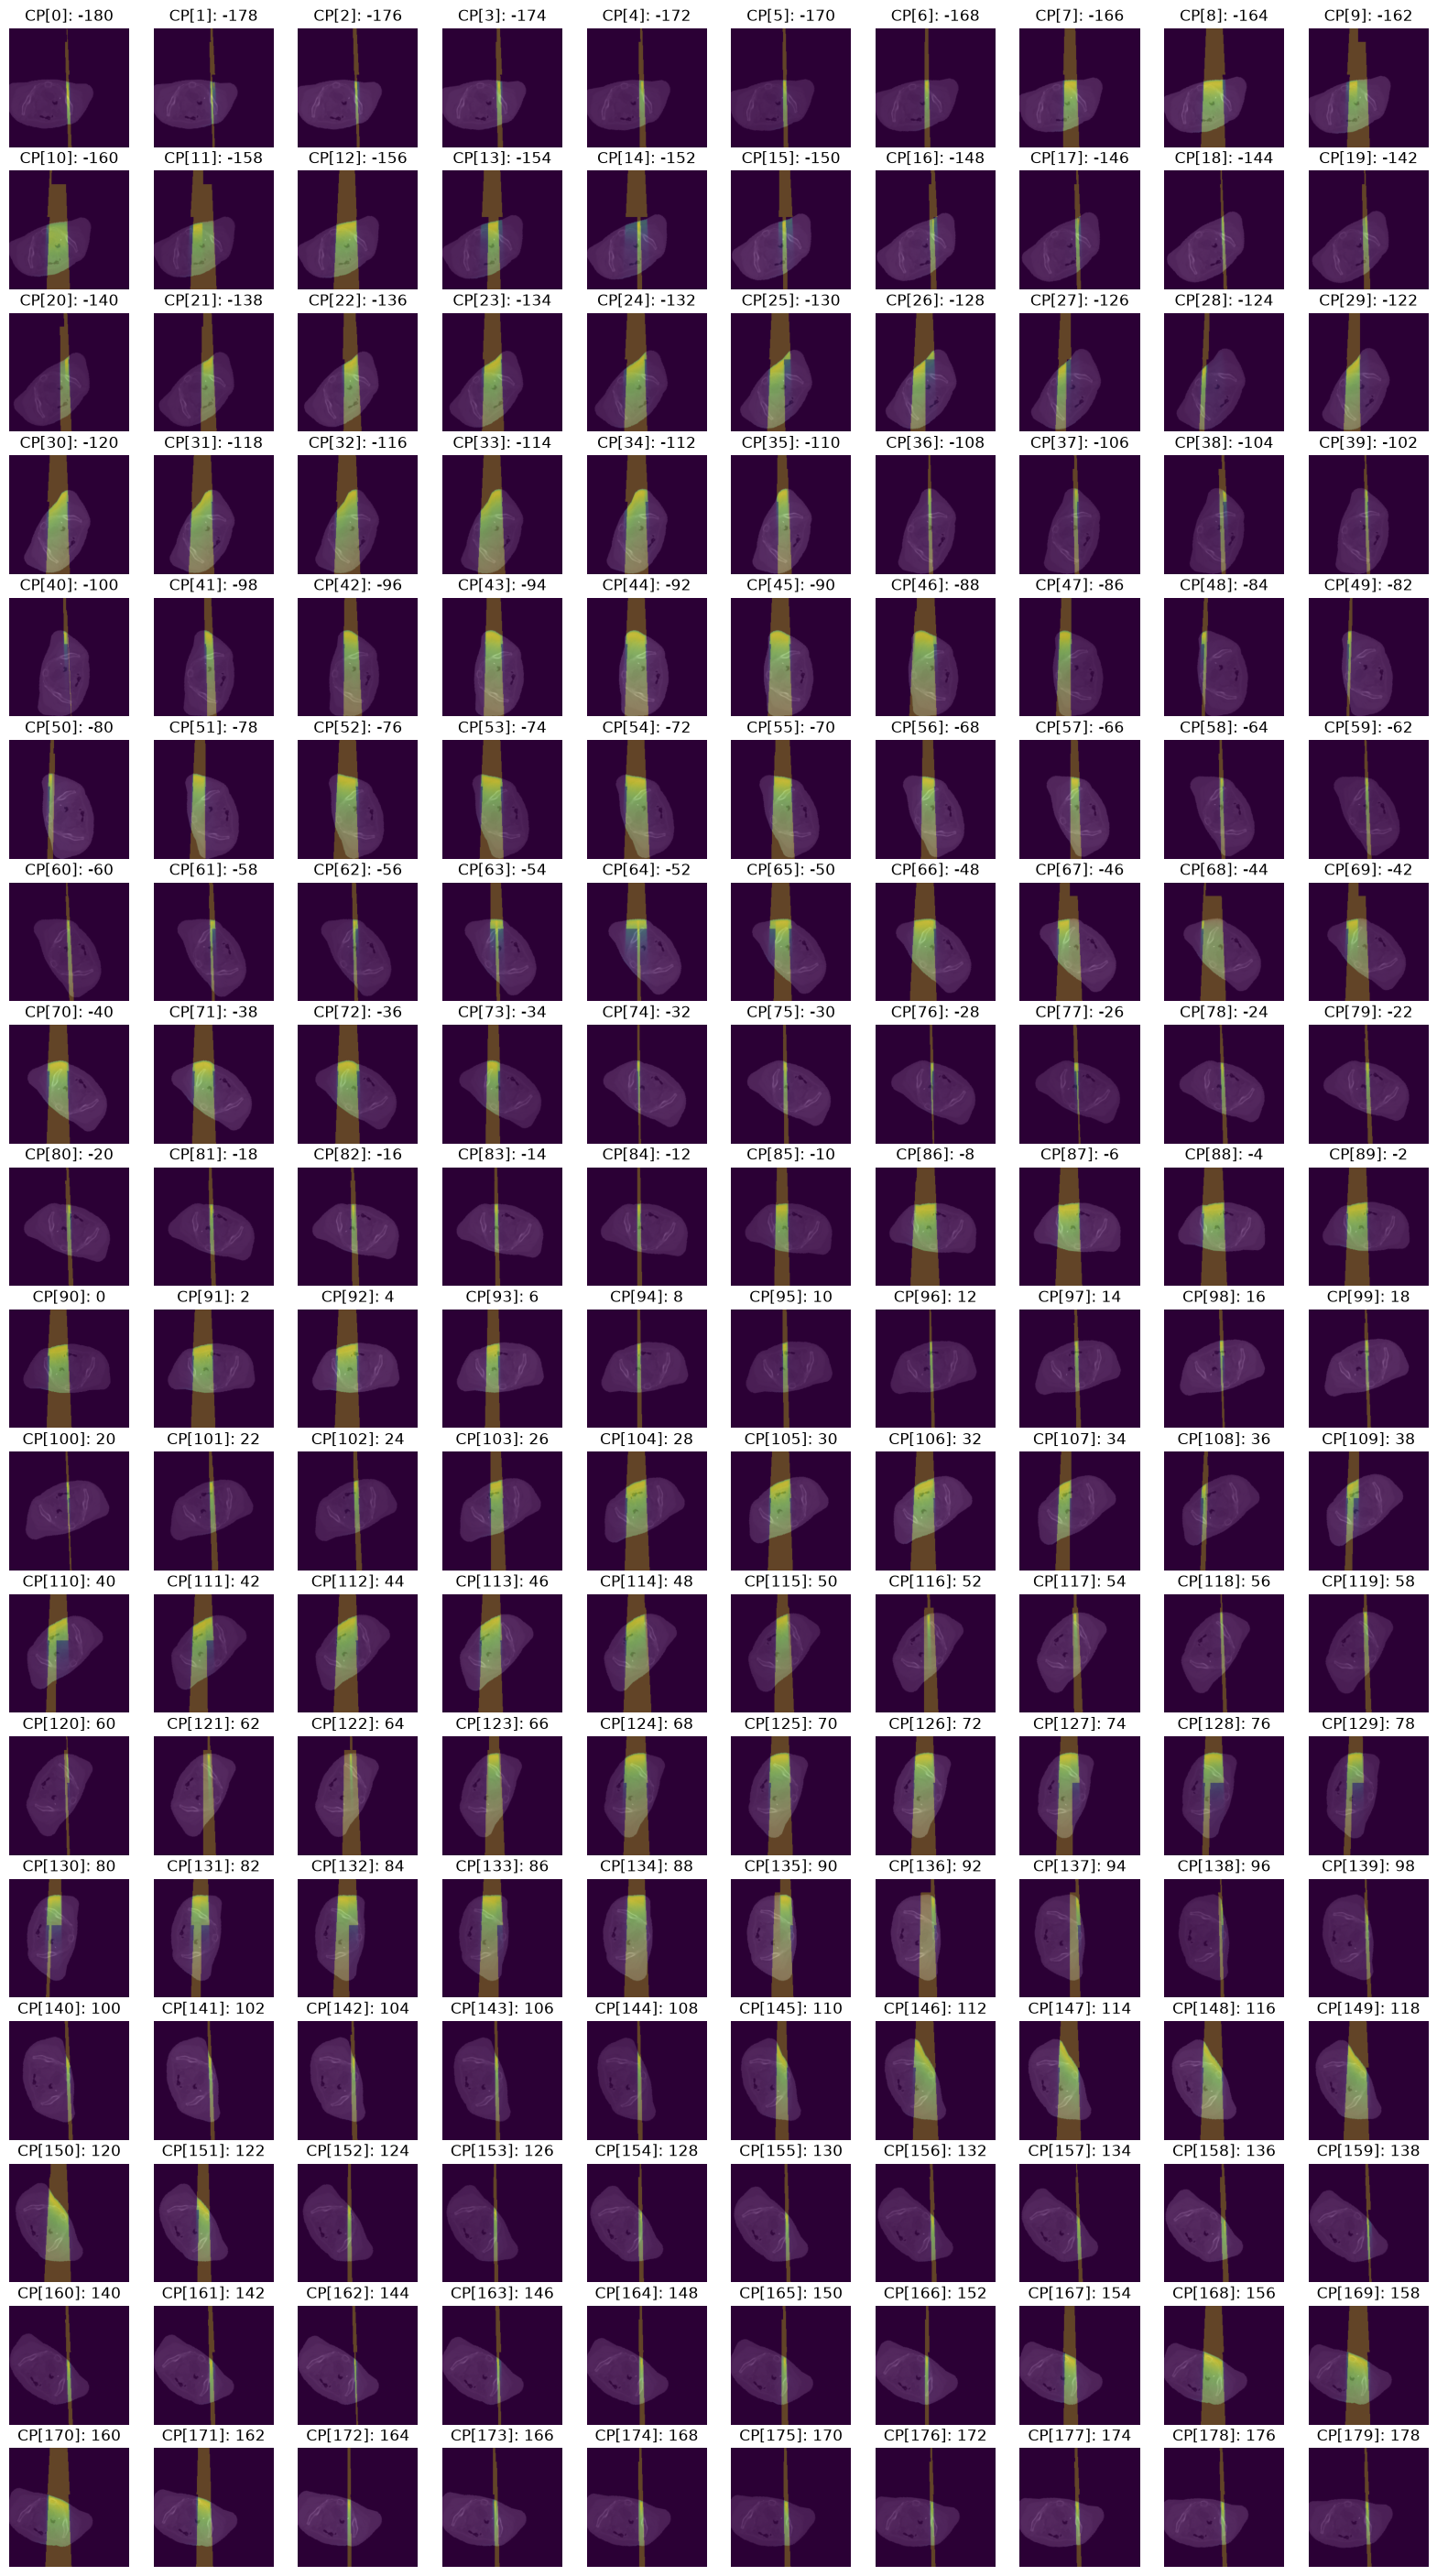

In [14]:
fig, ax = plt.subplots(18, 10, figsize=(20, 36))
ax = ax.ravel()

for i in range(180):
    ax[i].imshow(d.img_rot[i][102], cmap='gray')
    ax[i].imshow(d.dose[i][102], alpha=0.5)
    ax[i].imshow(d.bev[i][102], alpha=0.3)
    ax[i].axis('off')
    ax[i].set_title(f'CP[{i}]: {d.cp_info[i]["ga"]}')

(np.float64(-0.5), np.float64(248.5), np.float64(245.5), np.float64(-0.5))

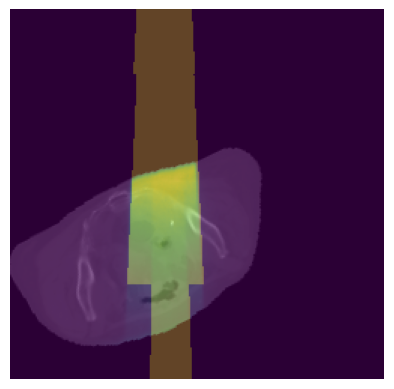

In [24]:
plt.imshow(d.img_rot[13][101], cmap='gray')
plt.imshow(d.dose[13][101], alpha=0.5)
plt.imshow(d.bev[13][101], alpha=0.3)
plt.axis('off')